In [1]:
# ============================================================
# 1) IMPORTAR LIBRERÍAS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

from ipywidgets import interact, IntSlider, FloatSlider, Dropdown

plt.rcParams["figure.figsize"] = (12, 4)

# ============================================================
# 2) GENERAR UNA SEÑAL DE PROCESO (HUMEDAD) CON RUIDO
# ============================================================
duracion_horas = 3
fs = 1  # 1 dato por segundo
n_muestras = duracion_horas * 60 * 60  # 10800

inicio = "2025-01-01 00:00:00"
tiempo = pd.date_range(start=inicio, periods=n_muestras, freq="S")
t = np.arange(n_muestras)

# Señal base (tendencia lenta + oscilación suave)
humedad_base = 20 + 3 * np.sin(2 * np.pi * t / (60 * 15)) - 0.002 * (t / 60)
humedad_base = np.clip(humedad_base, 8, 30)

# Agregar ruido blanco + picos -> lo que entrega el sensor
np.random.seed(42)
ruido = np.random.normal(loc=0.0, scale=0.8, size=n_muestras)
humedad = humedad_base + ruido

idx_picos = np.random.choice(n_muestras, size=25, replace=False)
humedad[idx_picos] += np.random.choice([5, -5, 8, -8], size=25)

# DataFrame con SOLO la señal medida (puedes agregar más columnas si quieres)
df = pd.DataFrame({"humedad": humedad}, index=tiempo)
df.index.name = "timestamp"

print("Columnas del df:", df.columns.tolist())
print(df.head())

# ============================================================
# 3) DEFINIR FUNCIONES DE FILTRADO
# ============================================================

def filtrar_promedio_movil(df, columna, window=5, center=True, nueva_col=None):
    """
    Filtro 1: Promedio móvil.
    - window: tamaño de ventana (nº de muestras)
    - center: True = ventana centrada
    """
    if nueva_col is None:
        nueva_col = f"{columna}_ma{window}"
    df[nueva_col] = df[columna].rolling(window=window, center=center).mean()
    return df

def filtrar_mediana_movil(df, columna, window=5, center=True, nueva_col=None):
    """
    Filtro 2: Mediana móvil.
    Más robusto a picos/outliers.
    """
    if nueva_col is None:
        nueva_col = f"{columna}_mediana{window}"
    df[nueva_col] = df[columna].rolling(window=window, center=center).median()
    return df

def filtrar_ema(df, columna, alpha=0.2, nueva_col=None):
    """
    Filtro 3: Promedio móvil exponencial (EMA).
    - alpha: 0–1, más chico = más suave.
    """
    if nueva_col is None:
        nueva_col = f"{columna}_ema{alpha}".replace(".", "_")
    df[nueva_col] = df[columna].ewm(alpha=alpha, adjust=False).mean()
    return df

def filtrar_butterworth(df, columna, fs=1.0, fc=1/300, order=3, nueva_col=None):
    """
    Filtro 4: Butterworth pasa-bajos.
    - fs : frecuencia de muestreo [Hz]
    - fc : frecuencia de corte [Hz]
    - order: orden del filtro
    """
    if nueva_col is None:
        nueva_col = f"{columna}_butter"

    w_norm = fc / (fs / 2)  # frecuencia normalizada
    b, a = butter(order, w_norm, btype="low", analog=False)

    x = df[columna].values
    x_filtrado = filtfilt(b, a, x)

    df[nueva_col] = x_filtrado
    return df

# ============================================================
# 4) PANEL DE CONTROL INTERACTIVO (4 GRÁFICOS SEPARADOS)
# ============================================================

columnas_numericas = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

def panel_control(columna,
                  window,
                  alpha,
                  fc_min,
                  order,
                  N):
    """
    Actualiza filtros y muestra 4 gráficos separados:
    - Original vs Promedio móvil
    - Original vs Mediana móvil
    - Original vs EMA
    - Original vs Butterworth
    """
    df_local = df.copy()

    # Convertir fc de minutos a Hz
    fc = 1.0 / (fc_min * 60.0)

    # Aplicar filtros
    df_local = filtrar_promedio_movil(df_local, columna,
                                      window=window, center=True,
                                      nueva_col=f"{columna}_ma")
    df_local = filtrar_mediana_movil(df_local, columna,
                                     window=window, center=True,
                                     nueva_col=f"{columna}_mediana")
    df_local = filtrar_ema(df_local, columna,
                           alpha=alpha,
                           nueva_col=f"{columna}_ema")
    df_local = filtrar_butterworth(df_local, columna,
                                   fs=fs, fc=fc, order=order,
                                   nueva_col=f"{columna}_butter")

    # Recortar para graficar
    N = min(N, len(df_local))
    df_plot = df_local.iloc[:N]

    # --- Gráfico 1: Promedio móvil ---
    plt.figure()
    plt.plot(df_plot.index, df_plot[columna],
             label=f"{columna} (original)", linewidth=0.8, alpha=0.8)
    plt.plot(df_plot.index, df_plot[f"{columna}_ma"],
             label=f"Promedio móvil (window={window})", linewidth=1.5)
    plt.ylabel("Valor")
    plt.xlabel("Tiempo")
    plt.title(f"Filtro 1: Promedio móvil - {columna}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Gráfico 2: Mediana móvil ---
    plt.figure()
    plt.plot(df_plot.index, df_plot[columna],
             label=f"{columna} (original)", linewidth=0.8, alpha=0.8)
    plt.plot(df_plot.index, df_plot[f"{columna}_mediana"],
             label=f"Mediana móvil (window={window})", linewidth=1.5)
    plt.ylabel("Valor")
    plt.xlabel("Tiempo")
    plt.title(f"Filtro 2: Mediana móvil - {columna}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Gráfico 3: EMA ---
    plt.figure()
    plt.plot(df_plot.index, df_plot[columna],
             label=f"{columna} (original)", linewidth=0.8, alpha=0.8)
    plt.plot(df_plot.index, df_plot[f"{columna}_ema"],
             label=f"EMA (alpha={alpha:.2f})", linewidth=1.5)
    plt.ylabel("Valor")
    plt.xlabel("Tiempo")
    plt.title(f"Filtro 3: EMA - {columna}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Gráfico 4: Butterworth ---
    plt.figure()
    plt.plot(df_plot.index, df_plot[columna],
             label=f"{columna} (original)", linewidth=0.8, alpha=0.8)
    plt.plot(df_plot.index, df_plot[f"{columna}_butter"],
             label=f"Butterworth (fc={fc_min} min, orden={order})", linewidth=1.5)
    plt.ylabel("Valor")
    plt.xlabel("Tiempo")
    plt.title(f"Filtro 4: Butterworth - {columna}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Lanzar el panel
interact(
    panel_control,
    columna=Dropdown(options=columnas_numericas, value="humedad", description="Columna"),
    window=IntSlider(min=3, max=61, step=2, value=5, description="Window"),
    alpha=FloatSlider(min=0.05, max=0.8, step=0.05, value=0.2, description="Alpha EMA"),
    fc_min=IntSlider(min=1, max=60, step=1, value=5, description="Fc [min]"),
    order=IntSlider(min=1, max=6, step=1, value=3, description="Orden"),
    N=IntSlider(min=500, max=len(df), step=500, value=2000, description="Muestras")
)


Columnas del df: ['humedad']
                       humedad
timestamp                     
2025-01-01 00:00:00  20.397371
2025-01-01 00:00:01  19.910299
2025-01-01 00:00:02  20.559971
2025-01-01 00:00:03  21.281151
2025-01-01 00:00:04  19.896309


/tmp/ipython-input-2401692568.py:21: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tiempo = pd.date_range(start=inicio, periods=n_muestras, freq="S")


interactive(children=(Dropdown(description='Columna', options=('humedad',), value='humedad'), IntSlider(value=…

<function __main__.panel_control(columna, window, alpha, fc_min, order, N)>

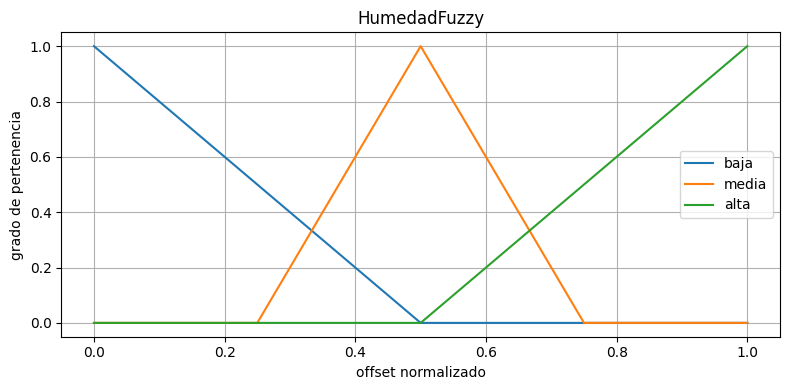

                       humedad hum_estado  hum_grado  hum_offset_norm
timestamp                                                            
2025-01-01 00:00:00  20.397371      media   0.745932         0.563517
2025-01-01 00:00:01  19.910299      media   0.834491         0.541377
2025-01-01 00:00:02  20.559971      media   0.716369         0.570908
2025-01-01 00:00:03  21.281151      media   0.585245         0.603689
2025-01-01 00:00:04  19.896309      media   0.837035         0.540741
2025-01-01 00:00:05  19.917222      media   0.833232         0.541692
2025-01-01 00:00:06  21.388797      media   0.565673         0.608582
2025-01-01 00:00:07  20.760264      media   0.679952         0.580012
2025-01-01 00:00:08  19.791618      media   0.856069         0.535983
2025-01-01 00:00:09  20.622120      media   0.705069         0.573733


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)

# ============================================================
# 1) DEFINIMOS crear_clase_fuzzy_norm AQUÍ MISMO
#    (versión simplificada basada en tu archivo)
# ============================================================
def crear_clase_fuzzy_norm(nombre_clase, x, **conjuntos):
    """
    Crea una clase fuzzy donde:
    offset_norm = (pv - lmin) / (lmax - lmin)  -> [0,1]
    conjuntos: diccionario de vectores de pertenencia (baja, media, alta, etc.)
    """
    x = np.array(x)

    class FuzzyNorm:
        def __init__(self):
            self.x = x
            self.conjuntos = {k: np.array(v) for k, v in conjuntos.items()}

        def evaluar(self, pv, lmin, lmax):
            # normalización a [0,1]
            if lmax == lmin:
                offset = 0.0
            else:
                offset = (pv - lmin) / (lmax - lmin)
            # saturar a [0,1]
            offset = max(0.0, min(1.0, offset))

            # calcular pertenencias por interpolación
            pertenencias = {}
            for nombre, y in self.conjuntos.items():
                pertenencias[nombre] = float(np.interp(offset, self.x, y))

            # conjunto dominante
            dominante = max(pertenencias, key=pertenencias.get)
            grado_dom = pertenencias[dominante]

            return dominante, grado_dom, offset, pertenencias

        def graficar(self):
            import matplotlib.pyplot as plt
            plt.figure()
            for nombre, y in self.conjuntos.items():
                plt.plot(self.x, y, label=nombre)
            plt.xlabel("offset normalizado")
            plt.ylabel("grado de pertenencia")
            plt.title(nombre_clase)
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return FuzzyNorm

# ============================================================
# 2) CONFIGURAR EL FUZZY PARA TU SEÑAL FILTRADA
# ============================================================

# Nombre de la columna filtrada en tu df
columna_filtrada = "humedad"   # <-- CAMBIA ESTO si tiene otro nombre

# Límites físicos de la variable (ejemplo: % de humedad)
lmin = 8    # mínimo esperado
lmax = 30   # máximo esperado

# Dominio normalizado [0,1]
offset = np.linspace(0, 1, 101)

# Conjuntos difusos: baja, media, alta

# BAJA: 1 en 0, va a 0 en 0.5
baja = np.where(offset <= 0.5, 1 - offset / 0.5, 0.0)

# ALTA: 0 en 0.5, va a 1 en 1.0
alta = np.where(offset >= 0.5, (offset - 0.5) / 0.5, 0.0)

# MEDIA: pico en 0.5, 0 en 0.25 y 0.75
media = np.where(
    (offset >= 0.25) & (offset <= 0.75),
    1 - np.abs(offset - 0.5) / 0.25,
    0.0
)

# Crear clase fuzzy e instancia
HumedadFuzzyClass = crear_clase_fuzzy_norm(
    "HumedadFuzzy",
    offset,
    baja=baja,
    media=media,
    alta=alta
)
hum_fuzzy = HumedadFuzzyClass()

# (Opcional) ver las formas
hum_fuzzy.graficar()

# ============================================================
# 3) FUNCIÓN PARA APLICAR EL FUZZY A CADA VALOR DE LA SEÑAL
# ============================================================
def fuzzificar_humedad(pv):
    """
    pv: valor de df[columna_filtrada] (ya filtrado).
    """
    dominante, grado_dom, offset_norm, pertenencias = hum_fuzzy.evaluar(pv, lmin, lmax)
    return pd.Series({
        "hum_estado": dominante,          # 'baja', 'media', 'alta'
        "hum_grado": grado_dom,           # grado del estado dominante
        "hum_offset_norm": offset_norm    # valor normalizado [0,1]
    })

# ============================================================
# 4) APLICAR A TU DATAFRAME df
#    (asumimos que df ya existe y tiene columna_filtrada)
# ============================================================
df[["hum_estado", "hum_grado", "hum_offset_norm"]] = df[columna_filtrada].apply(fuzzificar_humedad)

print(df[[columna_filtrada, "hum_estado", "hum_grado", "hum_offset_norm"]].head(10))


In [3]:
print(df["hum_estado"].value_counts())


hum_estado
media    9475
alta     1276
baja       49
Name: count, dtype: int64
